# DDRM Deblurring for GoPro Dataset

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = Path("../data/GoPro_dataset_custom")

BLUR_DIR = DATA_ROOT / "blur"
SHARP_DIR = DATA_ROOT / "sharp"

blur_images = sorted(BLUR_DIR.glob("*.png"))
sharp_images = sorted(SHARP_DIR.glob("*.png"))

print("Number of blur images:", len(blur_images))
print("Number of sharp images:", len(sharp_images))

print("\nFirst 5 blur images:")
for p in blur_images[:5]:
    print(p.name)

print("\nFirst 5 sharp images:")
for p in sharp_images[:5]:
    print(p.name)

Number of blur images: 22
Number of sharp images: 22

First 5 blur images:
000001 2.png
000001 3.png
000001 4.png
000001.png
000041.png

First 5 sharp images:
000001 2.png
000001 3.png
000001 4.png
000001.png
000041.png


In [6]:
blur_names = [p.name for p in blur_images]
sharp_names = [p.name for p in sharp_images]

missing_sharp = set(blur_names) - set(sharp_names)
missing_blur = set(sharp_names) - set(blur_names)

print("Missing sharp files:", missing_sharp)
print("Missing blur files:", missing_blur)

assert len(missing_sharp) == 0, "Some blur images do not have matching sharp images."
assert len(missing_blur) == 0, "Some sharp images do not have matching blur images."

print("All blur/sharp PNG pairs match by filename.")

Missing sharp files: set()
Missing blur files: set()
All blur/sharp PNG pairs match by filename.


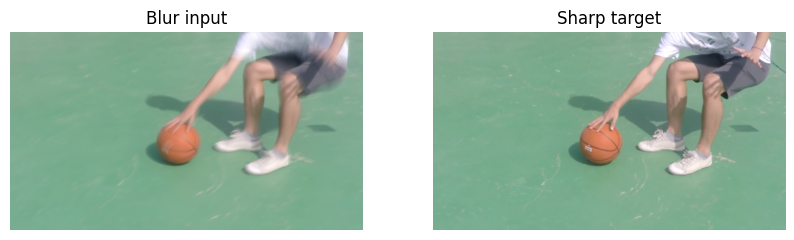

In [7]:
idx = 0

blur_img = Image.open(blur_images[idx]).convert("RGB")
sharp_img = Image.open(SHARP_DIR / blur_images[idx].name).convert("RGB")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(blur_img)
plt.title("Blur input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharp_img)
plt.title("Sharp target")
plt.axis("off")

plt.show()

## Setting LPIPS threshold (using OOD images)

In [ ]:
import os
from pathlib import Path
from PIL import Image
import torch
import torchvision.transforms as T
import lpips

PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
device = "cuda" if torch.cuda.is_available() else "cpu"

lpips_model = lpips.LPIPS(net="alex").to(device)
to_tensor = T.ToTensor()

def load_img(path):
    img = Image.open(path).convert("RGB")
    return to_tensor(img).unsqueeze(0).to(device)

def to_lpips_range(x):
    return x * 2 - 1

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [2]:
run_dirs = {
    5:  DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k5_strongerblur",
    10: DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k10_strongerblur",
    20: DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k20_strongerblur",
    30: DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k30_strongerblur",
    50: DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k50_strongerblur",
    100: DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k100_strongerblur",
}

In [3]:
results = []

num_images = 22

for k, folder in run_dirs.items():
    for idx in range(num_images):
        orig_path = folder / f"orig_{idx}.png"
        restored_path = folder / f"{idx}_-1.png"

        x0 = load_img(orig_path)
        xr = load_img(restored_path)

        with torch.no_grad():
            score = lpips_model(
                to_lpips_range(xr),
                to_lpips_range(x0)
            ).item()

        results.append((idx, k, score))
        print(f"image={idx}, steps={k}, LPIPS={score:.5f}")

image=0, steps=5, LPIPS=0.01538
image=1, steps=5, LPIPS=0.03070
image=2, steps=5, LPIPS=0.04018
image=3, steps=5, LPIPS=0.02817
image=4, steps=5, LPIPS=0.03068
image=5, steps=5, LPIPS=0.02529
image=6, steps=5, LPIPS=0.03430
image=7, steps=5, LPIPS=0.03963
image=8, steps=5, LPIPS=0.03847
image=9, steps=5, LPIPS=0.05876
image=10, steps=5, LPIPS=0.03593
image=11, steps=5, LPIPS=0.02382
image=12, steps=5, LPIPS=0.08345
image=13, steps=5, LPIPS=0.02340
image=14, steps=5, LPIPS=0.04057
image=15, steps=5, LPIPS=0.03119
image=16, steps=5, LPIPS=0.03074
image=17, steps=5, LPIPS=0.01845
image=18, steps=5, LPIPS=0.05907
image=19, steps=5, LPIPS=0.04690
image=20, steps=5, LPIPS=0.04882
image=21, steps=5, LPIPS=0.03680
image=0, steps=10, LPIPS=0.00940
image=1, steps=10, LPIPS=0.01980
image=2, steps=10, LPIPS=0.02279
image=3, steps=10, LPIPS=0.02008
image=4, steps=10, LPIPS=0.01668
image=5, steps=10, LPIPS=0.01742
image=6, steps=10, LPIPS=0.02035
image=7, steps=10, LPIPS=0.02986
image=8, steps=10, L

In [4]:
from collections import defaultdict

best_per_image = defaultdict(lambda: (None, float("inf")))

for idx, k, score in results:
    if score < best_per_image[idx][1]:
        best_per_image[idx] = (k, score)

print("\nBest step count per image:")
for idx in sorted(best_per_image):
    k, score = best_per_image[idx]
    print(f"image={idx}: best_k={k}, best_LPIPS={score:.5f}")


Best step count per image:
image=0: best_k=100, best_LPIPS=0.00267
image=1: best_k=100, best_LPIPS=0.00695
image=2: best_k=100, best_LPIPS=0.00568
image=3: best_k=100, best_LPIPS=0.00592
image=4: best_k=100, best_LPIPS=0.00699
image=5: best_k=100, best_LPIPS=0.00806
image=6: best_k=100, best_LPIPS=0.00436
image=7: best_k=100, best_LPIPS=0.00979
image=8: best_k=100, best_LPIPS=0.00680
image=9: best_k=100, best_LPIPS=0.01903
image=10: best_k=100, best_LPIPS=0.00278
image=11: best_k=100, best_LPIPS=0.00667
image=12: best_k=100, best_LPIPS=0.01894
image=13: best_k=100, best_LPIPS=0.00322
image=14: best_k=100, best_LPIPS=0.00264
image=15: best_k=100, best_LPIPS=0.00323
image=16: best_k=100, best_LPIPS=0.00820
image=17: best_k=100, best_LPIPS=0.00285
image=18: best_k=100, best_LPIPS=0.00857
image=19: best_k=100, best_LPIPS=0.00924
image=20: best_k=100, best_LPIPS=0.01752
image=21: best_k=100, best_LPIPS=0.01350


In [5]:
# Freeze reference LPIPS per image from your CURRENT results
# (do this once, do NOT recompute after adding new runs)

from collections import defaultdict

# build per-image lookup
lpips_lookup = defaultdict(dict)
for idx, k, score in results:
    lpips_lookup[idx][k] = score

# choose reference step per image = step with lowest LPIPS in CURRENT results
reference_step_per_image = {}
reference_lpips_per_image = {}

for idx, step_dict in lpips_lookup.items():
    best_k = min(step_dict, key=lambda k: step_dict[k])
    reference_step_per_image[idx] = best_k
    reference_lpips_per_image[idx] = step_dict[best_k]

print("Frozen references:")
for idx in sorted(reference_step_per_image):
    print(f"image={idx}, ref_step={reference_step_per_image[idx]}, ref_LPIPS={reference_lpips_per_image[idx]:.5f}")

Frozen references:
image=0, ref_step=100, ref_LPIPS=0.00267
image=1, ref_step=100, ref_LPIPS=0.00695
image=2, ref_step=100, ref_LPIPS=0.00568
image=3, ref_step=100, ref_LPIPS=0.00592
image=4, ref_step=100, ref_LPIPS=0.00699
image=5, ref_step=100, ref_LPIPS=0.00806
image=6, ref_step=100, ref_LPIPS=0.00436
image=7, ref_step=100, ref_LPIPS=0.00979
image=8, ref_step=100, ref_LPIPS=0.00680
image=9, ref_step=100, ref_LPIPS=0.01903
image=10, ref_step=100, ref_LPIPS=0.00278
image=11, ref_step=100, ref_LPIPS=0.00667
image=12, ref_step=100, ref_LPIPS=0.01894
image=13, ref_step=100, ref_LPIPS=0.00322
image=14, ref_step=100, ref_LPIPS=0.00264
image=15, ref_step=100, ref_LPIPS=0.00323
image=16, ref_step=100, ref_LPIPS=0.00820
image=17, ref_step=100, ref_LPIPS=0.00285
image=18, ref_step=100, ref_LPIPS=0.00857
image=19, ref_step=100, ref_LPIPS=0.00924
image=20, ref_step=100, ref_LPIPS=0.01752
image=21, ref_step=100, ref_LPIPS=0.01350


In [6]:
from collections import defaultdict

# ---- NEW: freeze reference once ----
def get_reference_lpips_per_image(results):
    """
    Freeze reference LPIPS per image based on CURRENT results.
    Should be run ONLY ONCE after coarse sweep.
    """
    ref_lpips = {}
    ref_step = {}

    for idx, k, lp in results:
        if idx not in ref_lpips or lp < ref_lpips[idx]:
            ref_lpips[idx] = lp
            ref_step[idx] = k

    return ref_lpips, ref_step


def coarse_kstar_relative(results, reference_lpips, epsilon=0.1):
    """
    Returns smallest k such that LPIPS(k) <= (1+epsilon)*reference
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    kstar_dict = {}
    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        chosen_k = None
        for k, lp in vals:
            if lp <= threshold:
                chosen_k = k
                break

        kstar_dict[idx] = chosen_k

    return kstar_dict


def find_refinement_intervals(results, reference_lpips, epsilon=0.1):
    """
    Uses FIXED reference instead of dynamic best LPIPS
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    intervals = {}

    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        first_k, first_lp = vals[0]
        if first_lp <= threshold:
            intervals[idx] = (None, first_k)
            continue

        low_k, high_k = None, None
        prev_k, prev_lp = vals[0]

        for k, lp in vals[1:]:
            if prev_lp > threshold and lp <= threshold:
                low_k = prev_k
                high_k = k
                break
            prev_k, prev_lp = k, lp

        if high_k is None:
            intervals[idx] = (vals[-1][0], None)
        else:
            intervals[idx] = (low_k, high_k)

    return intervals

### ----------------------- DO NOT TOUCH AGAIN, ONLY ONCE -----------------------

In [7]:
reference_lpips, reference_steps = get_reference_lpips_per_image(results)

print("Frozen reference:")
for i in sorted(reference_steps):
    print(f"image={i}, ref_step={reference_steps[i]}, ref_lpips={reference_lpips[i]:.5f}")

Frozen reference:
image=0, ref_step=100, ref_lpips=0.00267
image=1, ref_step=100, ref_lpips=0.00695
image=2, ref_step=100, ref_lpips=0.00568
image=3, ref_step=100, ref_lpips=0.00592
image=4, ref_step=100, ref_lpips=0.00699
image=5, ref_step=100, ref_lpips=0.00806
image=6, ref_step=100, ref_lpips=0.00436
image=7, ref_step=100, ref_lpips=0.00979
image=8, ref_step=100, ref_lpips=0.00680
image=9, ref_step=100, ref_lpips=0.01903
image=10, ref_step=100, ref_lpips=0.00278
image=11, ref_step=100, ref_lpips=0.00667
image=12, ref_step=100, ref_lpips=0.01894
image=13, ref_step=100, ref_lpips=0.00322
image=14, ref_step=100, ref_lpips=0.00264
image=15, ref_step=100, ref_lpips=0.00323
image=16, ref_step=100, ref_lpips=0.00820
image=17, ref_step=100, ref_lpips=0.00285
image=18, ref_step=100, ref_lpips=0.00857
image=19, ref_step=100, ref_lpips=0.00924
image=20, ref_step=100, ref_lpips=0.01752
image=21, ref_step=100, ref_lpips=0.01350


### ----------------------- END -----------------------

In [8]:
epsilon = 0.3

kstar = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.3

image=0, k*=50, interval=(30, 50)
image=1, k*=50, interval=(30, 50)
image=2, k*=100, interval=(50, 100)
image=3, k*=50, interval=(30, 50)
image=4, k*=50, interval=(30, 50)
image=5, k*=50, interval=(30, 50)
image=6, k*=100, interval=(50, 100)
image=7, k*=100, interval=(50, 100)
image=8, k*=50, interval=(30, 50)
image=9, k*=100, interval=(50, 100)
image=10, k*=100, interval=(50, 100)
image=11, k*=50, interval=(30, 50)
image=12, k*=50, interval=(30, 50)
image=13, k*=50, interval=(30, 50)
image=14, k*=100, interval=(50, 100)
image=15, k*=50, interval=(30, 50)
image=16, k*=50, interval=(30, 50)
image=17, k*=100, interval=(50, 100)
image=18, k*=100, interval=(50, 100)
image=19, k*=50, interval=(30, 50)
image=20, k*=50, interval=(30, 50)
image=21, k*=50, interval=(30, 50)


In [23]:
def binary_search_kstar(pass_fn, low_k, high_k):
    """
    Finds the smallest k in [low_k+1, high_k] that passes.
    Assumes:
      - low_k fails
      - high_k passes
    """
    lo = low_k + 1
    hi = high_k

    while lo < hi:
        mid = (lo + hi) // 2
        if pass_fn(mid):
            hi = mid
        else:
            lo = mid + 1

    return lo


def make_pass_fn(lpips_by_step, best_lpips, epsilon):
    """
    lpips_by_step: dict {step: lpips}
    Returns a function pass_fn(k) that checks whether
    LPIPS at step k is within (1 + epsilon) of the best LPIPS.
    """
    threshold = (1 + epsilon) * best_lpips

    def pass_fn(k):
        if k not in lpips_by_step:
            raise ValueError(f"Missing LPIPS for step {k}")
        return lpips_by_step[k] <= threshold

    return pass_fn


def get_dense_steps_from_interval(low_k, high_k):
    """
    Returns all integer steps in the refinement interval.
    Example: (30, 50) -> [31, 32, ..., 50]
    """
    if low_k is None or high_k is None:
        return []
    return list(range(low_k + 1, high_k + 1))

In [24]:
epsilon = 0.3
print(f"Refinement plan for epsilon = {epsilon}\n")

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]
    
    if low_k is None:
        print(f"image={idx}: already passes at the smallest tested step")
    elif high_k is None:
        print(f"image={idx}: did not pass within tested range; test larger steps")
    else:
        dense_steps = get_dense_steps_from_interval(low_k, high_k)
        print(f"image={idx}: refine in [{low_k}, {high_k}] -> test {dense_steps}")

Refinement plan for epsilon = 0.3

image=0: refine in [43, 44] -> test [44]
image=1: refine in [47, 48] -> test [48]
image=2: refine in [62, 63] -> test [63]
image=3: refine in [37, 38] -> test [38]
image=4: refine in [37, 38] -> test [38]
image=5: refine in [40, 41] -> test [41]
image=6: refine in [66, 68] -> test [67, 68]
image=7: refine in [54, 56] -> test [55, 56]
image=8: refine in [47, 48] -> test [48]
image=9: refine in [54, 56] -> test [55, 56]
image=10: refine in [71, 73] -> test [72, 73]
image=11: refine in [31, 32] -> test [32]
image=12: refine in [41, 42] -> test [42]
image=13: refine in [40, 41] -> test [41]
image=14: refine in [57, 59] -> test [58, 59]
image=15: refine in [45, 46] -> test [46]
image=16: refine in [38, 39] -> test [39]
image=17: refine in [43, 44] -> test [44]
image=18: refine in [62, 63] -> test [63]
image=19: refine in [43, 44] -> test [44]
image=20: refine in [40, 41] -> test [41]
image=21: refine in [30, 31] -> test [31]


In [25]:
from collections import defaultdict

# build per-image LPIPS lookup
lpips_lookup = defaultdict(dict)

for idx, k, score in results:
    lpips_lookup[idx][k] = score

In [26]:
def make_pass_fn_for_image(idx, epsilon):
    best_lp = best_lpips[idx]
    threshold = (1 + epsilon) * best_lp

    def pass_fn(k):
        if k not in lpips_lookup[idx]:
            raise ValueError(f"LPIPS not computed yet for image {idx}, step {k}")
        return lpips_lookup[idx][k] <= threshold

    return pass_fn

def next_binary_step(idx, low_k, high_k):
    return (low_k + high_k) // 2

In [27]:
epsilon = 0.3
print(f"Binary search suggestions (epsilon={epsilon}):\n")

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]

    if low_k is None or high_k is None:
        print(f"image={idx}: no refinement needed")
        continue

    mid = next_binary_step(idx, low_k, high_k)

    print(f"image={idx}: try step {mid} (between {low_k} and {high_k})")

Binary search suggestions (epsilon=0.3):

image=0: try step 43 (between 43 and 44)
image=1: try step 47 (between 47 and 48)
image=2: try step 62 (between 62 and 63)
image=3: try step 37 (between 37 and 38)
image=4: try step 37 (between 37 and 38)
image=5: try step 40 (between 40 and 41)
image=6: try step 67 (between 66 and 68)
image=7: try step 55 (between 54 and 56)
image=8: try step 47 (between 47 and 48)
image=9: try step 55 (between 54 and 56)
image=10: try step 72 (between 71 and 73)
image=11: try step 31 (between 31 and 32)
image=12: try step 41 (between 41 and 42)
image=13: try step 40 (between 40 and 41)
image=14: try step 58 (between 57 and 59)
image=15: try step 45 (between 45 and 46)
image=16: try step 38 (between 38 and 39)
image=17: try step 43 (between 43 and 44)
image=18: try step 62 (between 62 and 63)
image=19: try step 43 (between 43 and 44)
image=20: try step 40 (between 40 and 41)
image=21: try step 30 (between 30 and 31)


### All the runs suggested based on the algorithm

In [15]:
run_dirs[40] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k40_strongerblur"
run_dirs[75] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k75_strongerblur"

In [16]:
run_dirs[35] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k35_strongerblur"
run_dirs[45] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k45_strongerblur"
run_dirs[62] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k62_strongerblur"

In [17]:
run_dirs[32] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k32_strongerblur"
run_dirs[37] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k37_strongerblur"
run_dirs[42] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k42_strongerblur"
run_dirs[47] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k47_strongerblur"
run_dirs[56] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k56_strongerblur"
run_dirs[68] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k68_strongerblur"

In [18]:
run_dirs[31] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k31_strongerblur"
run_dirs[38] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k38_strongerblur"
run_dirs[41] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k41_strongerblur"
run_dirs[43] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k43_strongerblur"
run_dirs[46] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k46_strongerblur"
run_dirs[48] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k48_strongerblur"
run_dirs[53] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k53_strongerblur"
run_dirs[59] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k59_strongerblur"
run_dirs[65] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k65_strongerblur"
run_dirs[71] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k71_strongerblur"

In [19]:
run_dirs[30] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k30_strongerblur"
run_dirs[39] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k39_strongerblur"
run_dirs[44] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k44_strongerblur"
run_dirs[54] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k54_strongerblur"
run_dirs[57] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k57_strongerblur"
run_dirs[63] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k63_strongerblur"
run_dirs[66] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k66_strongerblur"
run_dirs[73] = DDR_ROOT / "exp" / "image_samples" / "run_gopro_sharp_k73_strongerblur"

In [20]:
run_dirs

{5: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k5_strongerblur'),
 10: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k10_strongerblur'),
 20: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k20_strongerblur'),
 30: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k30_strongerblur'),
 50: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k50_strongerblur'),
 100: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm/exp/image_samples/run_gopro_sharp_k100_strongerblur'),
 40: PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-A